## Importing  Libraries :

In [25]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load the Dataset :

In [26]:
# Loading the preprocessed data :
file_path=os.path.join(os.path.dirname(os.getcwd()),'data','preprocessed','Final_result_df.csv')
try:
    if os.path.exists(file_path) is not True :
        raise FileNotFoundError(f'The required file path is not found : {file_path}')
    df=pd.read_csv(file_path)
    print('Dataset Loaded Succesfully ...')
    print(f'Dataset have : {df.shape[0] } rows and {df.shape[1]} columns.')
except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f'Unexpected error is occcured :{str(e)}')

Dataset Loaded Succesfully ...
Dataset have : 5 rows and 9 columns.


In [27]:
df

,Model,Tuned MAE,Tuned RMSE,Tuned R2,Test MAE,Test RMSE,Test R2,MAE Change,R2 Gain
0,XGBoost,893.798523,1633.030312,0.872098,867.013123,1639.558935,0.871073,-26.785400,0.001025
1,GradientBoosting,899.593802,1657.838385,0.868183,1252.296568,2014.824770,0.805301,352.702766,0.062881
2,LightGBM,974.183241,1701.012905,0.861228,1007.552964,1710.101451,0.859741,33.369723,0.001487
3,RandomForest,904.970855,1723.292466,0.857568,844.190440,1703.321547,0.860851,-60.780415,-0.003282
4,SVR,1274.103271,1998.376990,0.808467,1213.428580,2041.717604,0.800069,-60.674691,0.008398


In [28]:
df.to_string

<bound method DataFrame.to_string of               Model    Tuned MAE   Tuned RMSE  Tuned R2     Test MAE  \
0           XGBoost   893.798523  1633.030312  0.872098   867.013123   
1  GradientBoosting   899.593802  1657.838385  0.868183  1252.296568   
2          LightGBM   974.183241  1701.012905  0.861228  1007.552964   
3      RandomForest   904.970855  1723.292466  0.857568   844.190440   
4               SVR  1274.103271  1998.376990  0.808467  1213.428580   

     Test RMSE   Test R2  MAE Change   R2 Gain  
0  1639.558935  0.871073  -26.785400  0.001025  
1  2014.824770  0.805301  352.702766  0.062881  
2  1710.101451  0.859741   33.369723  0.001487  
3  1703.321547  0.860851  -60.780415 -0.003282  
4  2041.717604  0.800069  -60.674691  0.008398  >

# .melt() is used to reshape your DataFrame from wide format to long format, which is the format Seaborn prefers for grouped bar plots.

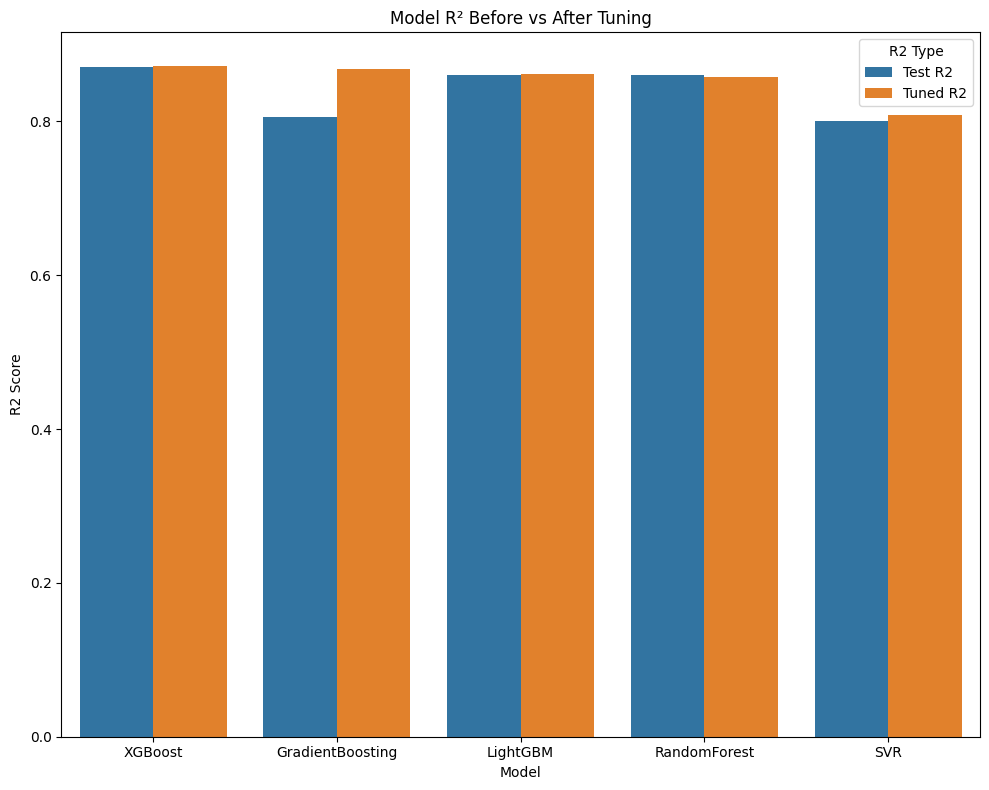

In [29]:
# Test R² vs Tuned R² for Each Model :
plt.figure(figsize=(10,8))
df_melted = df.melt(id_vars='Model', value_vars=['Test R2', 'Tuned R2'],var_name='R2 Type', value_name='R2 Score')
sns.barplot(data=df_melted, x='Model', y='R2 Score', hue='R2 Type')
plt.title('Model R² Before vs After Tuning')
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


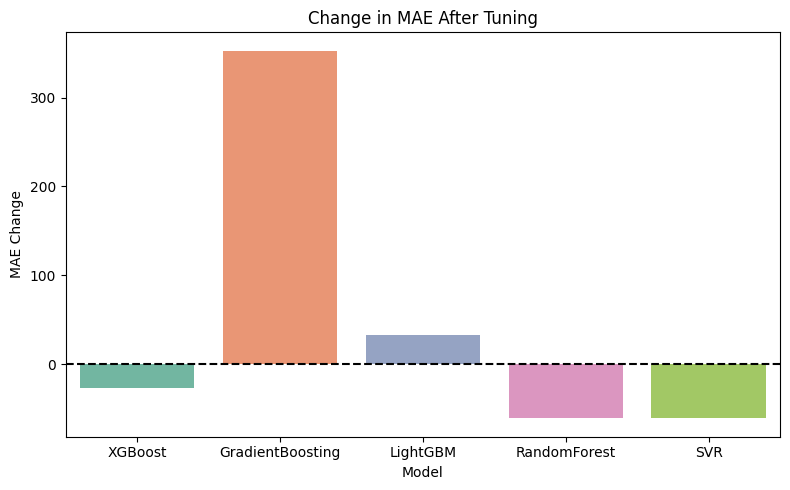

In [30]:
# MAE Change Across Models :
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Model', y='MAE Change', palette='Set2')
plt.axhline(0, color='black', linestyle='--')
plt.title('Change in MAE After Tuning')
plt.xticks()
plt.tight_layout()
plt.show()


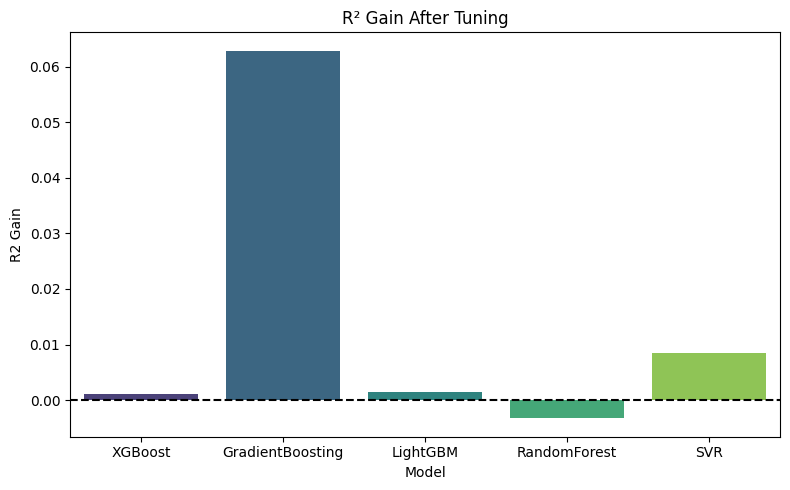

In [33]:
# R2 Gain Across Models :
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Model', y='R2 Gain', palette='viridis')
plt.axhline(0, color='black', linestyle='--')
plt.title('R² Gain After Tuning')
plt.xticks()
plt.tight_layout()
plt.show()


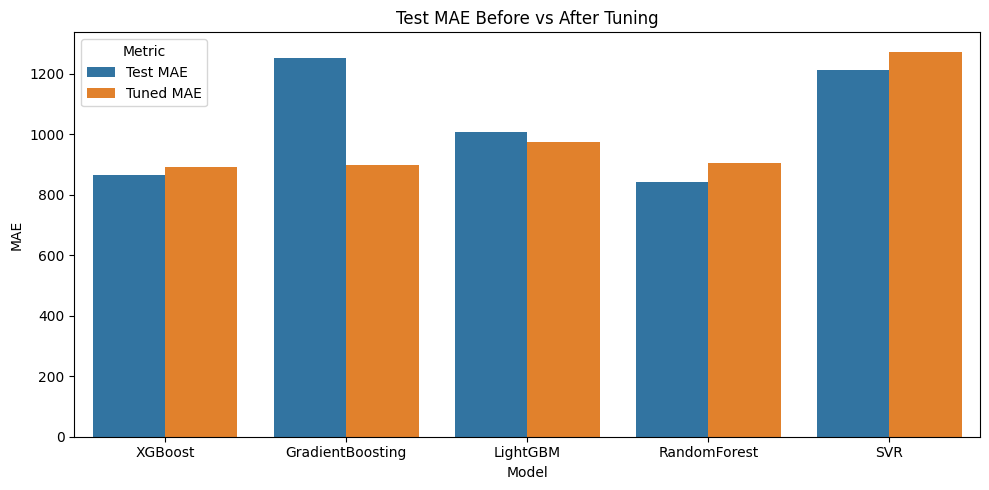

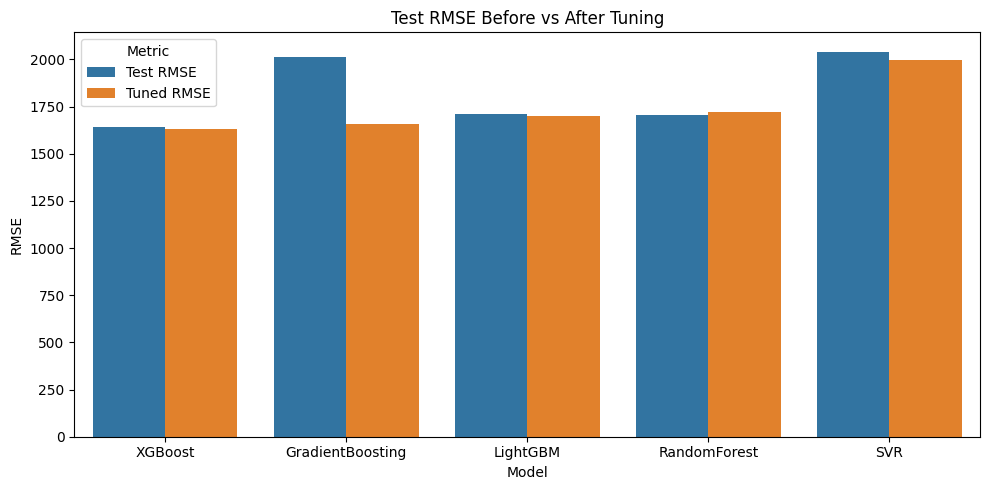

In [32]:
# MAE / RMSE (Before vs After) :
# MAE
plt.figure(figsize=(10, 5))
df_mae = df[['Model', 'Test MAE', 'Tuned MAE']].melt(id_vars='Model', var_name='Metric', value_name='MAE')
sns.barplot(data=df_mae, x='Model', y='MAE', hue='Metric')
plt.title('Test MAE Before vs After Tuning')
plt.xticks()
plt.tight_layout()
plt.show()

# RMSE
plt.figure(figsize=(10, 5))
df_rmse =df[['Model', 'Test RMSE', 'Tuned RMSE']].melt(id_vars='Model', var_name='Metric', value_name='RMSE')
sns.barplot(data=df_rmse, x='Model', y='RMSE', hue='Metric')
plt.title('Test RMSE Before vs After Tuning')
plt.xticks()
plt.tight_layout()
plt.show()


## Model Performance Summary: Before vs After Hyperparameter Tuning :

This section summarizes the impact of hyperparameter tuning on different regression models based on evaluation metrics: R², MAE, and RMSE.

### 1. R² Score
- **GradientBoosting** showed a significant improvement in R² after tuning (~0.80 to ~0.87), indicating better model fit.
- **XGBoost** and **LightGBM** already had high R² values and showed slight improvements (~0.88 to ~0.89).
- **RandomForest** remained largely unchanged.
- **SVR** showed a modest gain but still underperformed compared to tree-based models.

### 2. Mean Absolute Error (MAE)
- **GradientBoosting** experienced the largest drop in MAE (~1250 to ~900), demonstrating improved accuracy.
- **LightGBM** showed a minor decrease in MAE, indicating a slight improvement.
- **XGBoost**, **RandomForest**, and **SVR** experienced an increase in MAE after tuning, suggesting potential overfitting or ineffective tuning.

### 3. Root Mean Squared Error (RMSE)
- **GradientBoosting** achieved the most significant reduction in RMSE (~2020 to ~1650), confirming overall improvement.
- **XGBoost** and **LightGBM** had small improvements in RMSE.
- **RandomForest** and **SVR** showed minimal to no improvement in RMSE.

### 4. General Observations
- **GradientBoosting** consistently showed the best improvement across all metrics after tuning, making it the most positively impacted model.
- **XGBoost** and **LightGBM** were stable performers with minor improvements, suggesting they were already well-optimized.
- **RandomForest** and **SVR** either showed no improvement or worsened after tuning, indicating tuning may not have been effective for these models.


**Conclusion:** Hyperparameter tuning had the most positive effect on the GradientBoosting model, with modest gains for LightGBM and XGBoost. Other models saw limited or negative impact from tuning.
